# Common

In [142]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from typing import Optional
from dataclasses import dataclass

sys.path.append('../')

In [143]:
np.set_printoptions(threshold=sys.maxsize, linewidth=150)

In [144]:
@dataclass
class PlotParams:
    
    linestyle:  str = "-"
    color:      str = "k"
    linewidth:  float = 1.0
    marker:     Optional[str] = None
    markersize: float = 1.0
    label:      str = ""
    capsize:    float = 3.0
    markevery:  int = 1

class Plotter:

    def __init__(self, title: str = None, xlabel: str = None, ylabel: str = None, figsize: tuple = (16, 9)):
        
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.ax.set_title(title, fontsize=20, pad=30)
        self.ax.set_xlabel(xlabel, fontsize=18, labelpad=20)
        self.ax.set_ylabel(ylabel, fontsize=18, labelpad=20)

    def add_plot(self, x: np.ndarray, y: np.ndarray, params: PlotParams):

        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
            marker      = params.marker,
            markersize  = params.markersize,
            markevery   = params.markevery
        )

    def finalize_and_show(self, save_path: Optional[str] = None):

        self.ax.minorticks_on()
        self.ax.grid(True, which='both', linestyle='--', alpha=0.3)
        self.ax.legend(fontsize=14, loc='best', frameon=True, fancybox=True, framealpha=0.9)
        self.ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.5)
        self.ax.tick_params(axis='both', which='minor', length=4, width=1)
        self.fig.tight_layout()

        if save_path:
            self.fig.savefig(save_path)
            print(f"График сохранен в файл: {save_path}")

        plt.show()
        plt.close(self.fig)

In [145]:
# --- Константы (СИ) для значений по умолчанию ---
E_CHARGE = 4.8e-10  # Элементарный заряд (СГС)
M_ELECTRON = 9.1e-28  # Масса электрона (г)
C_LIGHT = 3e10       # Скорость света (см/с)

def get_trajectory_np(s, E, H, m=M_ELECTRON, e_charge=E_CHARGE, c_light=C_LIGHT):
    """
    Основная функция для расчета траектории (t, x, y, z) на основе s, E, H,
    использующая NumPy и np.isclose для сравнения.
    
    Принимает:
    s: Параметр s (может быть скаляром или массивом)
    E: Напряженность электрического поля
    H: Напряженность магнитного поля
    m, e_charge, c_light: Константы
    
    Возвращает:
    словарь {'t': t, 'x': x, 'y': y, 'z': z} с результатами в виде NumPy массивов.
    """
    
    # Сравниваем E и H с помощью np.isclose
    e_equal_h = np.isclose(E, H)

    # Инициализируем s как массив, чтобы операции были векторизованы
    s_val = np.asarray(s)
    shape = s_val.shape if s_val.ndim > 0 else 1
    
    ct = np.zeros(shape)
    x = np.zeros(shape)
    y = np.zeros(shape)
    z = np.zeros(shape)

    try:
        if E > H and not e_equal_h:
            print("hello1")
            # --- Случай 1: E > H ---
            diff_sq = E**2 - H**2
            sqrt_diff = np.sqrt(diff_sq)
            alpha = (e_charge * sqrt_diff) / (m * c_light**2)
            
            # Проверка для alpha -> 0 с использованием np.isclose
            if np.isclose(alpha, 0):
                common_term_part = s_val
            else:
                common_term_part = np.sinh(alpha * s_val) / alpha
            
            common_term = common_term_part - s_val
            
            ct = s_val + (E**2 / diff_sq) * common_term
            x = (E * H / diff_sq) * common_term
            
            y = (E * m * c_light**2 * (np.cosh(alpha * s_val) - 1)) / (e_charge * diff_sq)

        elif E < H and not e_equal_h:
            print("hello2")
            # --- Случай 2: E < H ---
            diff_sq_abs = H**2 - E**2
            denom = E**2 - H**2
            sqrt_diff = np.sqrt(diff_sq_abs)
            alpha = (e_charge * sqrt_diff) / (m * c_light**2)

            # Проверка для alpha -> 0 с использованием np.isclose
            if np.isclose(alpha, 0):
                common_term_part = s_val
            else:
                common_term_part = np.sin(alpha * s_val) / alpha

            common_term = common_term_part - s_val

            ct = s_val + (E**2 / denom) * common_term
            x = (E * H / denom) * common_term
            
            y = (E * m * c_light**2 * (1 - np.cos(alpha * s_val))) / (e_charge * diff_sq_abs)
        
        else: # E = H (Проверено с помощью np.isclose)
            print("hello3")
            # --- Случай 3: E = H ---
            if np.isclose(E, 0):
                # Случай E = H = 0
                ct = s_val
                x = np.zeros(shape)
                y = np.zeros(shape)
            else:
                # Используем формулы из *конечной* (упрощенной) матрицы
                alpha = (e_charge * E) / (m * c_light**2)
                
                s_sq = s_val**2
                s_cubed = s_val**3
                
                alpha_sq = alpha**2
                
                common_term = (alpha_sq * s_cubed) / 6
                
                ct = s_val + common_term
                x = common_term
                y = (alpha * s_sq) / 2

    except (ValueError, ZeroDivisionError, Exception):
        # В случае ошибки возвращаем NaN
        nan_result = np.full(shape, np.nan)
        return {'t': nan_result, 'x': nan_result, 'y': nan_result, 'z': z}

    # Финальный шаг: вычисляем t из ct
    t = ct / c_light
    return {'t': t, 'x': x, 'y': y, 'z': z}

# --- Требуемые функции t(s), x(s), y(s), z(s) ---

def t(s, E, H, m=M_ELECTRON, e_charge=E_CHARGE, c_light=C_LIGHT):
    """Вычисляет t(s, E, H) с использованием NumPy и np.isclose."""
    return get_trajectory_np(s, E, H, m, e_charge, c_light)['t']

def x(s, E, H, m=M_ELECTRON, e_charge=E_CHARGE, c_light=C_LIGHT):
    """Вычисляет x(s, E, H) с использованием NumPy и np.isclose."""
    return get_trajectory_np(s, E, H, m, e_charge, c_light)['x']

def y(s, E, H, m=M_ELECTRON, e_charge=E_CHARGE, c_light=C_LIGHT):
    """Вычисляет y(s, E, H) с использованием NumPy и np.isclose."""
    return get_trajectory_np(s, E, H, m, e_charge, c_light)['y']

def z(s, E, H, m=M_ELECTRON, e_charge=E_CHARGE, c_light=C_LIGHT):
    """Вычисляет z(s, E, H) с использованием NumPy и np.isclose."""
    return get_trajectory_np(s, E, H, m, e_charge, c_light)['z']

# --- Пример использования --

In [146]:
H = 1.0 # H = 1 Гаусс
s_scale = 1000 # Характерный масштаб s (см)

In [147]:
s_arr_1 = np.linspace(0, 50*s_scale, 1000)
t_arr_1 = t(s_arr_1, H/2, H)
x_arr_1 = x(s_arr_1, H/2, H)
y_arr_1 = y(s_arr_1, H/2, H)
z_arr_1 = z(s_arr_1, H/2, H)

s_arr_2 = np.linspace(0, 9*s_scale, 1000)
t_arr_2 = t(s_arr_2, H, H)
x_arr_2 = x(s_arr_2, H, H)
y_arr_2 = y(s_arr_2, H, H)
z_arr_2 = z(s_arr_2, H, H)

s_arr_3 = np.linspace(0, 5*s_scale, 1000)
t_arr_3 = t(s_arr_3, 2*H, H)
x_arr_3 = x(s_arr_3, 2*H, H)
y_arr_3 = y(s_arr_3, 2*H, H)
z_arr_3 = z(s_arr_3, 2*H, H)

hello2
hello2
hello2
hello2
hello3
hello3
hello3
hello3
hello1
hello1
hello1
hello1


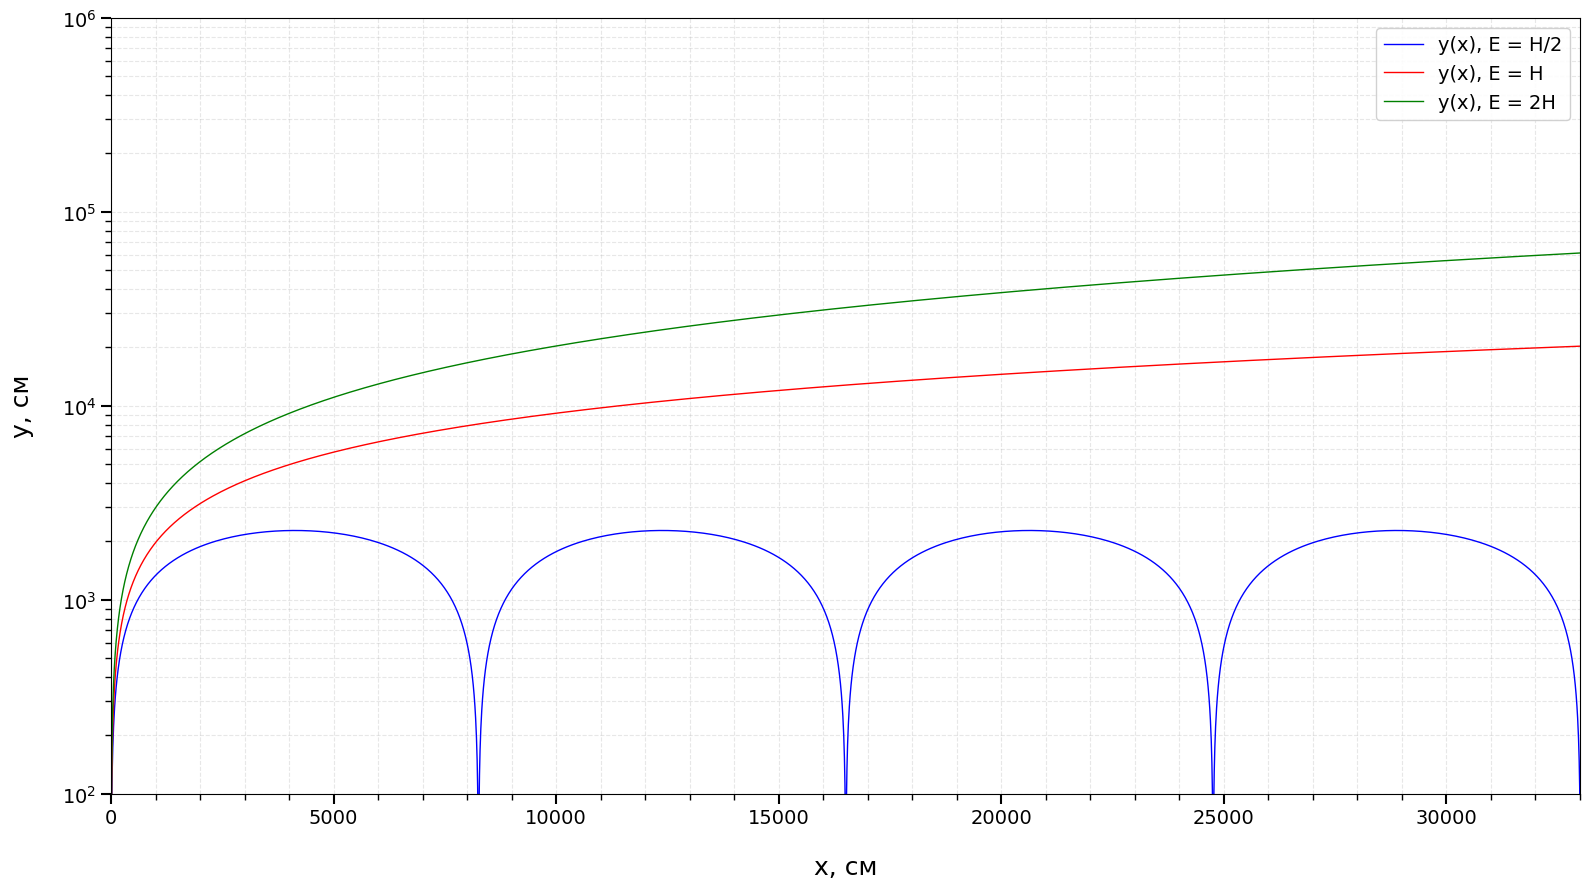

In [148]:

plotter = Plotter(
    title='',
    xlabel='x, см',
    ylabel="y, см"
)

plot_args_dict = \
{
    "y(x)_1":          PlotParams(linestyle="-", color="blue", linewidth=1, label='y(x), E = H/2'),
    "y(x)_2":          PlotParams(linestyle="-", color="red", linewidth=1, label='y(x), E = H'),
    "y(x)_3":          PlotParams(linestyle="-", color="green", linewidth=1, label='y(x), E = 2H'),
}

plotter.add_plot(x_arr_1, y_arr_1, plot_args_dict["y(x)_1"])
plotter.add_plot(x_arr_2, y_arr_2, plot_args_dict["y(x)_2"])
plotter.add_plot(x_arr_3, y_arr_3, plot_args_dict["y(x)_3"])
plt.yscale("log")
plt.xlim([0, 33000])
plt.ylim([1e2, 1e6])
plotter.finalize_and_show()

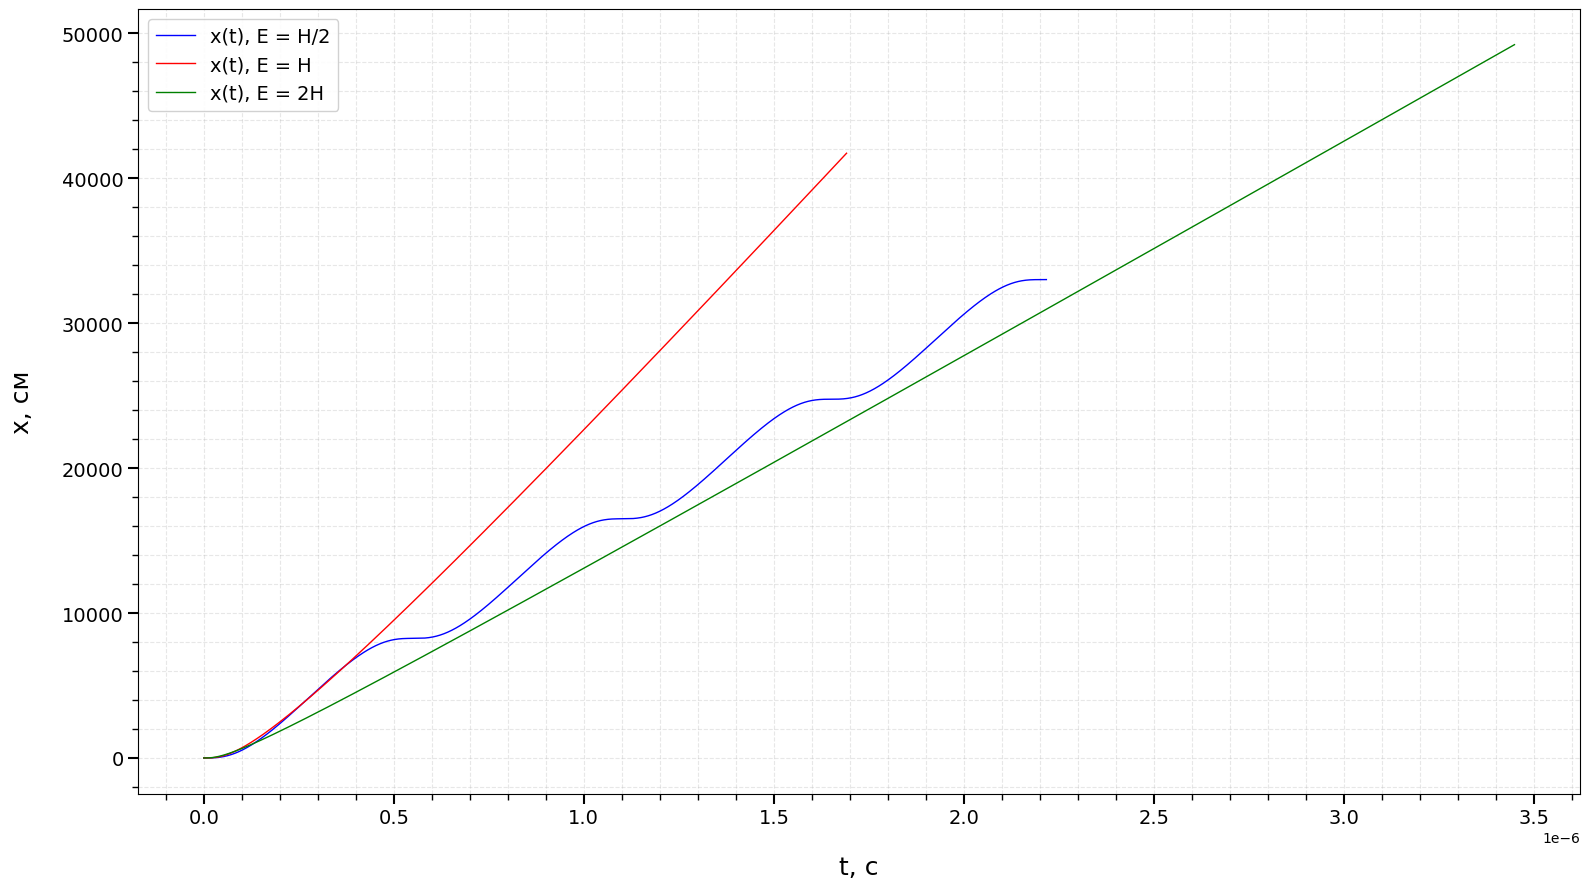

In [149]:
plotter = Plotter(
    title='',
    xlabel='t, с',
    ylabel="x, см"
)

plot_args_dict = \
{
    "y(x)_1":          PlotParams(linestyle="-", color="blue", linewidth=1, label='x(t), E = H/2'),
    "y(x)_2":          PlotParams(linestyle="-", color="red", linewidth=1, label='x(t), E = H'),
    "y(x)_3":          PlotParams(linestyle="-", color="green", linewidth=1, label='x(t), E = 2H'),
}

plotter.add_plot(t_arr_1, x_arr_1, plot_args_dict["y(x)_1"])
plotter.add_plot(t_arr_2, x_arr_2, plot_args_dict["y(x)_2"])
plotter.add_plot(t_arr_3, x_arr_3, plot_args_dict["y(x)_3"])
# plt.yscale("log")
# plt.xlim([0, 33000])
# plt.ylim([1e2, 1e6])
plotter.finalize_and_show()

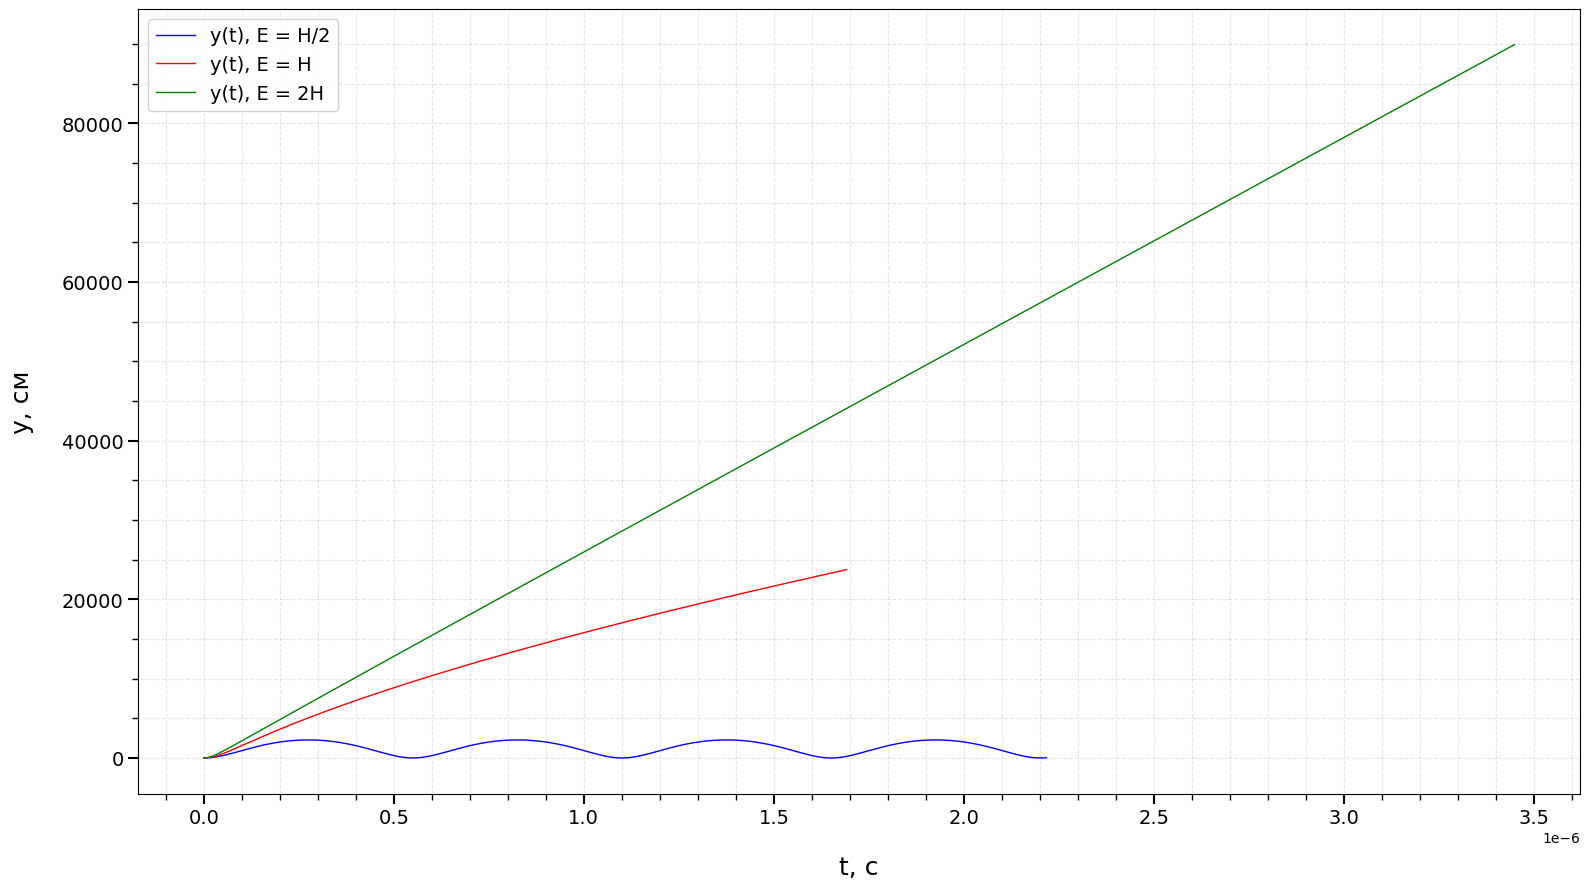

In [150]:
plotter = Plotter(
    title='',
    xlabel='t, с',
    ylabel="y, см"
)

plot_args_dict = \
{
    "y(x)_1":          PlotParams(linestyle="-", color="blue", linewidth=1, label='y(t), E = H/2'),
    "y(x)_2":          PlotParams(linestyle="-", color="red", linewidth=1, label='y(t), E = H'),
    "y(x)_3":          PlotParams(linestyle="-", color="green", linewidth=1, label='y(t), E = 2H'),
}

plotter.add_plot(t_arr_1, y_arr_1, plot_args_dict["y(x)_1"])
plotter.add_plot(t_arr_2, y_arr_2, plot_args_dict["y(x)_2"])
plotter.add_plot(t_arr_3, y_arr_3, plot_args_dict["y(x)_3"])
plotter.finalize_and_show()

In [151]:
a = 0.5
E = a * H

kappa = E_CHARGE * np.sqrt(H**2-E**2) / (M_ELECTRON * C_LIGHT**2)

print(2*np.pi/kappa)

12379.180660898537


In [21]:
from mpmath import mp
import numpy as np
mp.dps = 1000  # устанавливаем точность в 100 000 знаков
print(np.array(str(mp.pi)))

3.14159265358979323846264338327950288419716939937510582097494459230781640628620899862803482534211706798214808651328230664709384460955058223172535940812848111745028410270193852110555964462294895493038196442881097566593344612847564823378678316527120190914564856692346034861045432664821339360726024914127372458700660631558817488152092096282925409171536436789259036001133053054882046652138414695194151160943305727036575959195309218611738193261179310511854807446237996274956735188575272489122793818301194912983367336244065664308602139494639522473719070217986094370277053921717629317675238467481846766940513200056812714526356082778577134275778960917363717872146844090122495343014654958537105079227968925892354201995611212902196086403441815981362977477130996051870721134999999837297804995105973173281609631859502445945534690830264252230825334468503526193118817101000313783875288658753320838142061717766914730359825349042875546873115956286388235378759375195778185778053217122680661300192787661119590921642019